In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data-export (1) (1).csv")

In [3]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


# Data Preprocessing

In [4]:
df.columns = df.iloc[0]
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [5]:
df = df.drop(index = 0).reset_index(drop = True)
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [6]:
df.columns = ['channel group',	'Datehour', 'Users',	'Sessions',	'Engaged sessions',	'Average engagement time per session',	'Engaged sessions per user',	'Events per session',	'Engagement rate',	'Event']

In [7]:
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3182 non-null   object
 1   Datehour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event                                3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [9]:
df['Datehour'] = pd.to_datetime(df['Datehour'], format ="%Y%m%d%H")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   Datehour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   object        
 3   Sessions                             3182 non-null   object        
 4   Engaged sessions                     3182 non-null   object        
 5   Average engagement time per session  3182 non-null   object        
 6   Engaged sessions per user            3182 non-null   object        
 7   Events per session                   3182 non-null   object        
 8   Engagement rate                      3182 non-null   object        
 9   Event                                3182 non-null   object        
dtypes: datetime6

In [11]:
df['Hour'] = df['Datehour'].dt.hour

In [12]:
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001,20


In [13]:
numeric_col = df.columns.drop(['channel group', 'Datehour'])
df[numeric_col] = df[numeric_col].apply(pd.to_numeric)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   Datehour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event                                3182 non-null   int64         
 10  Hour        

In [15]:
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [16]:
df.describe()

,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# Data Visualisation

# Session and User over time

In [17]:
sns.set(style = 'whitegrid')

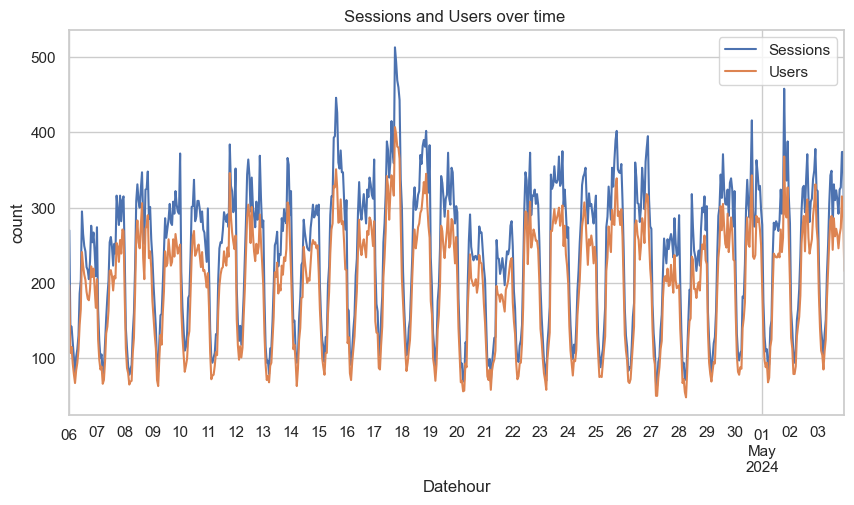

In [18]:
plt.figure(figsize = (10,5))
df.groupby('Datehour')[['Sessions', 'Users']].sum().plot(ax=plt.gca())
plt.title('Sessions and Users over time ')
plt.xlabel('Datehour')
plt.ylabel('count')
plt.show()

# Total user by channel

C:\Users\Mayank Sharma\AppData\Local\Temp\ipykernel_12076\3303645060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x = 'channel group', y = 'Users', estimator = np.sum, palette = 'magma')


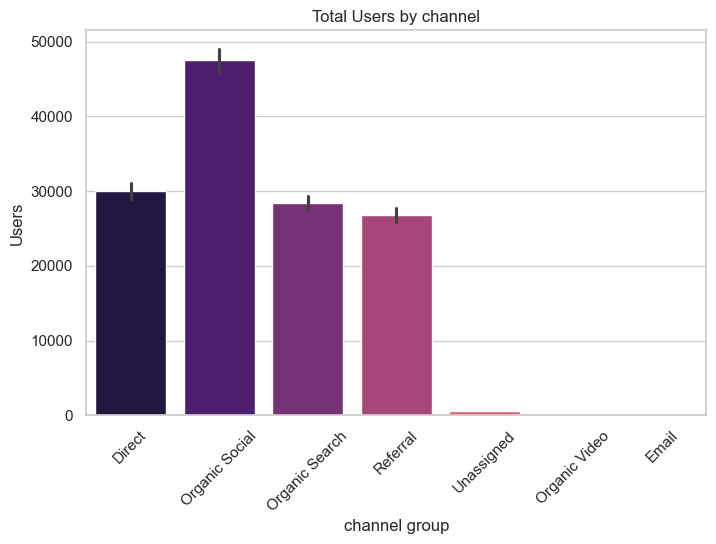

In [19]:
plt.figure(figsize = (8, 5))
sns.barplot(df, x = 'channel group', y = 'Users', estimator = np.sum, palette = 'magma')
plt.title('Total Users by channel')
plt.xticks(rotation = 45)
plt.show()

# Average Engagement time by channel

C:\Users\Mayank Sharma\AppData\Local\Temp\ipykernel_12076\1729450134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'channel group', y = 'Average engagement time per session', estimator = np.mean, palette = 'magma')


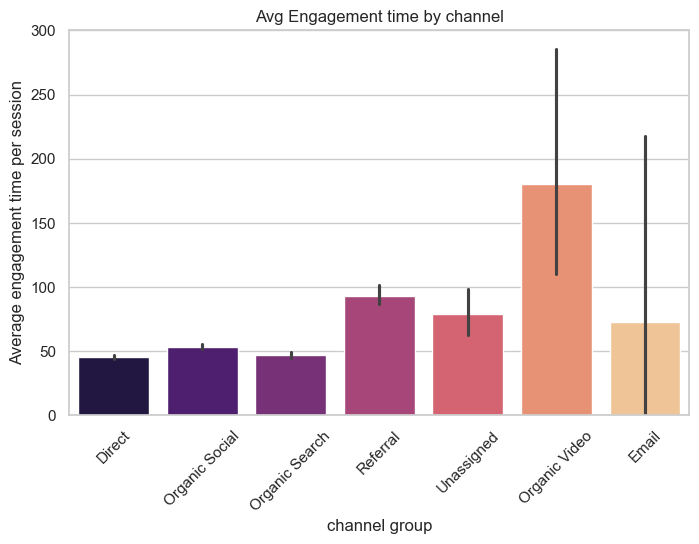

In [20]:
plt.figure(figsize = (8,5))
sns.barplot(data = df, x = 'channel group', y = 'Average engagement time per session', estimator = np.mean, palette = 'magma')
plt.title('Avg Engagement time by channel')
plt.xticks(rotation = 45)
plt.show()

C:\Users\Mayank Sharma\AppData\Local\Temp\ipykernel_12076\855304618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'channel group', y = 'Engagement rate', palette = 'coolwarm')


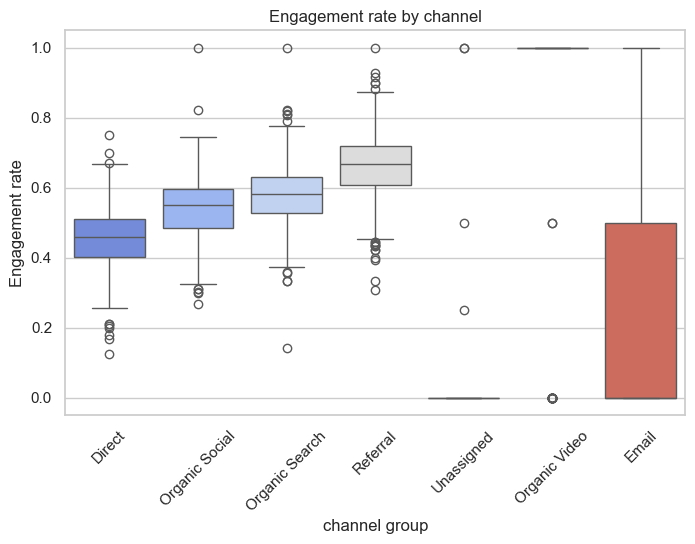

In [21]:
plt.figure(figsize = (8,5))
sns.boxplot(data = df, x = 'channel group', y = 'Engagement rate', palette = 'coolwarm')
plt.title('Engagement rate by channel')
plt.xticks(rotation = 45)
plt.show()

# Engaged vs non-Engaged Session

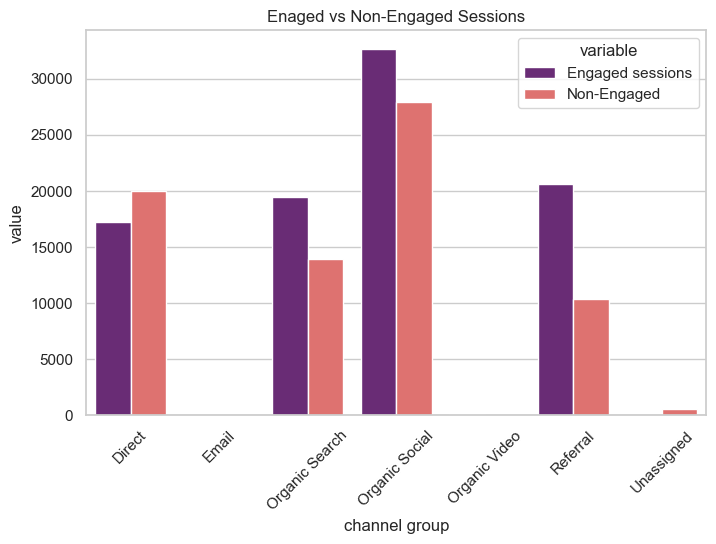

In [22]:
session_df = df.groupby('channel group')[['Sessions','Engaged sessions']].sum().reset_index()
session_df['Non-Engaged'] = session_df['Sessions'] - session_df['Engaged sessions']
session_df_melted = session_df.melt(id_vars='channel group', value_vars = ['Engaged sessions', 'Non-Engaged'])

plt.figure(figsize = (8,5))
sns.barplot(data = session_df_melted, x = 'channel group', y = 'value', hue = 'variable', palette = 'magma')
plt.title('Enaged vs Non-Engaged Sessions')
plt.xticks(rotation = 45)
plt.show()

# Trafic by hour and channel

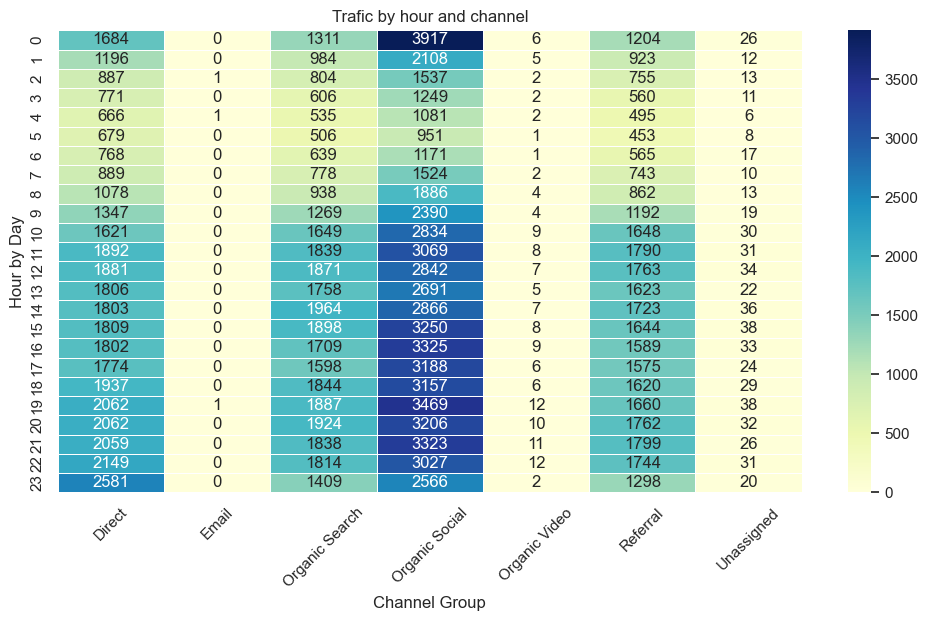

In [23]:
heatmap_data = df.groupby(['Hour','channel group'])['Sessions'].sum().unstack().fillna(0)

plt.figure(figsize = (12,6))
sns.heatmap(heatmap_data, cmap = 'YlGnBu', annot = True, fmt='.0f', linewidths = .5)
plt.title('Trafic by hour and channel')
plt.xlabel('Channel Group')
plt.ylabel('Hour by Day')
plt.xticks(rotation = 45)
plt.show()

# Engagement rate vs Session rate

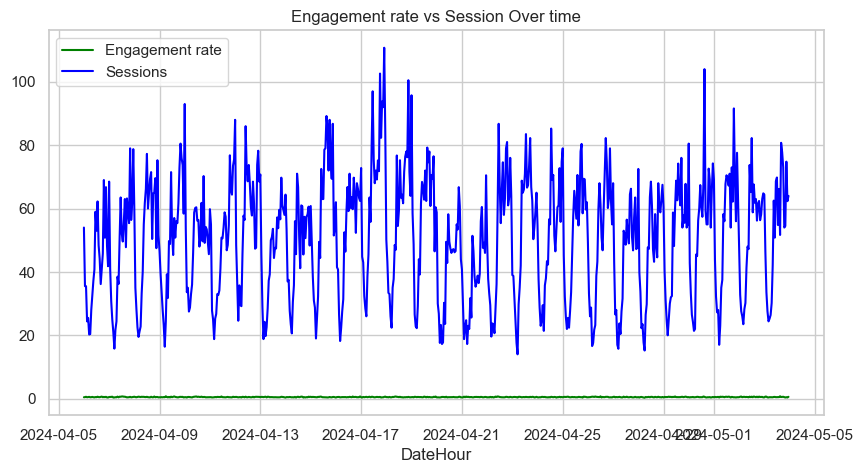

In [24]:
df_plot = df.groupby('Datehour')[['Engagement rate', 'Sessions']].mean().reset_index()

plt.figure(figsize = (10,5))
plt.plot(df_plot['Datehour'], df_plot['Engagement rate'], label = 'Engagement rate', color = 'green')
plt.plot(df_plot['Datehour'], df_plot['Sessions'], label = 'Sessions', color = 'blue')
plt.title('Engagement rate vs Session Over time')
plt.xlabel('DateHour')
plt.legend()
plt.show()